# CyberGuard-ID EDA Notebook

Tujuan utama:
- Memvalidasi kualitas data (missing values, duplikasi, struktur fitur).
- Menganalisis distribusi label dan representasi kanal/sumber data.
- Mengecek sinyal risiko kebocoran informasi (label leakage) dari distribusi sumber.
- Menghasilkan insight terstruktur yang siap dipakai di laporan/presentasi kompetisi.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "processed_cyber_data.csv"
REPORT_DIR = PROJECT_ROOT / "reports" / "eda"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"EDA report dir: {REPORT_DIR}")

Project root: /Users/muhammadayyas/Documents/cyberguard-id
Dataset path: /Users/muhammadayyas/Documents/cyberguard-id/data/processed/processed_cyber_data.csv
EDA report dir: /Users/muhammadayyas/Documents/cyberguard-id/reports/eda


In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset tidak ditemukan: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
display(df.head(5))
display(pd.DataFrame({"column": df.columns, "dtype": [str(x) for x in df.dtypes]}))

Rows: 22,399
Columns: 5


,processed_text,label,platform,has_dangerous_link,contains_urgency
0,Plg Yth Simcard anda mendptkan bonus poin plus...,1,SMS,0,0
1,Iya ih ko sedih sih gtau kapan lg ke bandung,0,SMS,0,0
2,Kalau mau bikin model controller mending per a...,0,SMS,0,0
3,Selamat nama1 Semoga selalu menempuh hidup yan...,0,SMS,0,0
4,Tingkatkan nilai isi ulang Anda selanjutnya mi...,1,SMS,0,0


,column,dtype
0,processed_text,object
1,label,int64
2,platform,object
3,has_dangerous_link,int64
4,contains_urgency,int64


## 1) Data Quality Checks

In [3]:
required_cols = ["processed_text", "label", "platform", "has_dangerous_link", "contains_urgency"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Kolom wajib belum ada: {missing_required}")

null_counts = df[required_cols].isna().sum()
duplicate_text = df.duplicated(subset=["processed_text"]).sum()
empty_text = (df["processed_text"].fillna("").astype(str).str.strip() == "").sum()

quality_summary = pd.DataFrame({
    "metric": [
        "row_count",
        "column_count",
        "duplicate_processed_text",
        "empty_processed_text",
    ],
    "value": [len(df), len(df.columns), int(duplicate_text), int(empty_text)],
})

display(quality_summary)
display(pd.DataFrame({"column": null_counts.index, "null_count": null_counts.values}))

,metric,value
0,row_count,22399
1,column_count,5
2,duplicate_processed_text,147
3,empty_processed_text,0


,column,null_count
0,processed_text,0
1,label,0
2,platform,0
3,has_dangerous_link,0
4,contains_urgency,0


## 2) Distribusi Label

,label,count,pct
0,0,11455,51.14
1,1,10944,48.86


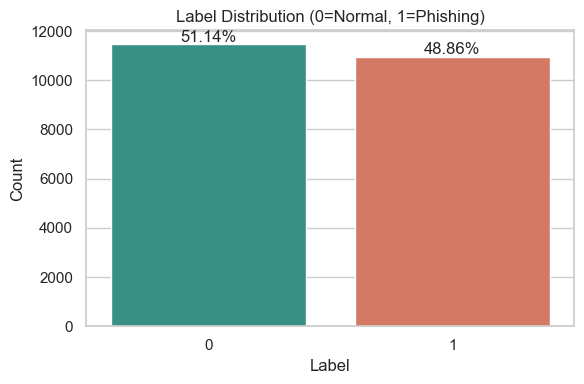

Saved: /Users/muhammadayyas/Documents/cyberguard-id/reports/eda/eda_label_distribution.png


In [10]:
label_counts = df["label"].value_counts(dropna=False).sort_index()
label_pct = (df["label"].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2)
label_table = pd.DataFrame({"label": label_counts.index, "count": label_counts.values, "pct": label_pct.values})
display(label_table)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=label_table,
    x="label",
    y="count",
    hue="label",
    palette=["#2A9D8F", "#E76F51"],
    dodge=False,
    legend=False,
    ax=ax,
)
ax.set_title("Label Distribution (0=Normal, 1=Phishing)")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, row in label_table.iterrows():
    ax.text(i, row["count"] + max(label_table["count"]) * 0.01, f"{row['pct']:.2f}%", ha="center")
plt.tight_layout()
out_path = REPORT_DIR / "eda_label_distribution.png"
plt.savefig(out_path, dpi=200)
plt.show()
print(f"Saved: {out_path}")

## 3) Distribusi Sumber/Kanal

,platform,count,pct
0,News_Hoax,10257,45.79
1,News_Antara,3875,17.30
2,News_Detik,3500,15.63
3,News_Kompas,3498,15.62
4,SMS,1173,5.24
5,WhatsApp,70,0.31
6,Email,26,0.12


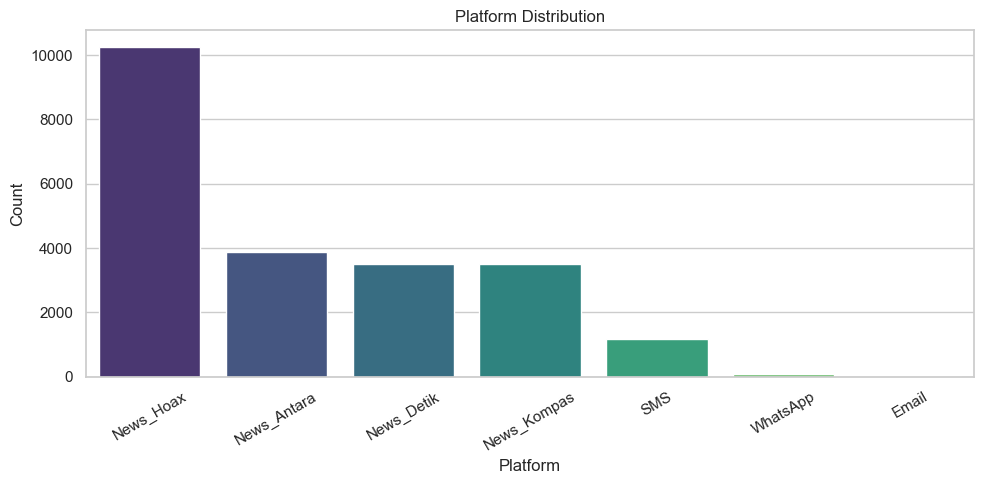

Saved: /Users/muhammadayyas/Documents/cyberguard-id/reports/eda/eda_platform_distribution.png


In [11]:
platform_counts = df["platform"].value_counts().reset_index()
platform_counts.columns = ["platform", "count"]
platform_counts["pct"] = (platform_counts["count"] / len(df) * 100).round(2)
display(platform_counts)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=platform_counts,
    x="platform",
    y="count",
    hue="platform",
    palette="viridis",
    dodge=False,
    legend=False,
    ax=ax,
)
ax.set_title("Platform Distribution")
ax.set_xlabel("Platform")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
out_path = REPORT_DIR / "eda_platform_distribution.png"
plt.savefig(out_path, dpi=200)
plt.show()
print(f"Saved: {out_path}")

## 4) Label vs Platform (Leakage Risk Check)

label,0,1
platform,,
Email,3,23
News_Antara,3875,0
News_Detik,3500,0
News_Hoax,0,10257
News_Kompas,3498,0
SMS,573,600
WhatsApp,6,64


label,0,1
platform,,
Email,11.54,88.46
News_Antara,100.00,0.00
News_Detik,100.00,0.00
News_Hoax,0.00,100.00
News_Kompas,100.00,0.00
SMS,48.85,51.15
WhatsApp,8.57,91.43


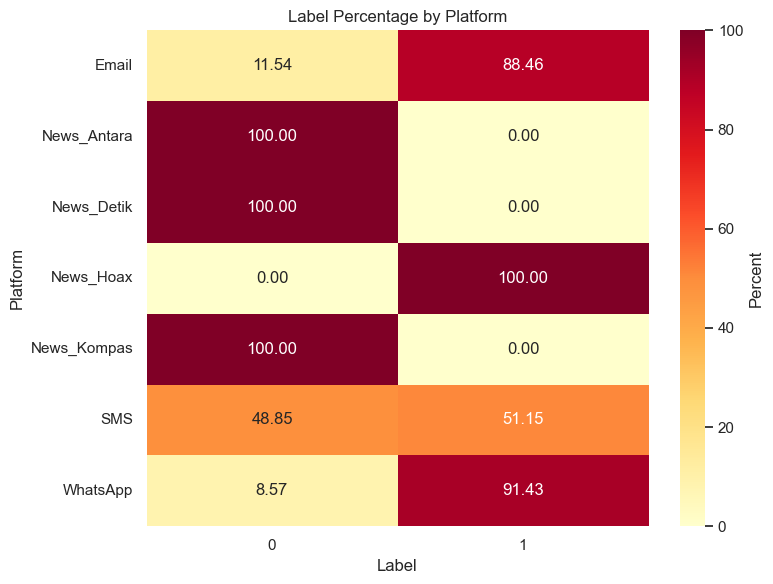

Saved: /Users/muhammadayyas/Documents/cyberguard-id/reports/eda/eda_label_by_platform_heatmap.png
Potential leakage platforms (>=99% single label): ['News_Antara', 'News_Detik', 'News_Hoax', 'News_Kompas']
Small sample platforms (<100 rows): ['Email', 'WhatsApp']


In [6]:
ct_counts = pd.crosstab(df["platform"], df["label"])
ct_pct = (pd.crosstab(df["platform"], df["label"], normalize="index") * 100).round(2)
display(ct_counts)
display(ct_pct)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(ct_pct, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={"label": "Percent"}, ax=ax)
ax.set_title("Label Percentage by Platform")
ax.set_xlabel("Label")
ax.set_ylabel("Platform")
plt.tight_layout()
out_path = REPORT_DIR / "eda_label_by_platform_heatmap.png"
plt.savefig(out_path, dpi=200)
plt.show()
print(f"Saved: {out_path}")

dominant_label_pct = ct_pct.max(axis=1)
potential_leakage_platforms = dominant_label_pct[dominant_label_pct >= 99.0].index.tolist()
small_sample_platforms = ct_counts.sum(axis=1)[ct_counts.sum(axis=1) < 100].index.tolist()

print("Potential leakage platforms (>=99% single label):", potential_leakage_platforms)
print("Small sample platforms (<100 rows):", small_sample_platforms)

## 5) Analisis Fitur Risiko

,has_dangerous_link,contains_urgency
label,,
0,0.21,8.60
1,1.16,12.49


,has_dangerous_link,contains_urgency
platform,,
Email,76.92,80.77
News_Antara,0.21,8.72
News_Detik,0.37,9.06
News_Hoax,0.19,11.14
News_Kompas,0.09,9.26
SMS,2.73,14.32
WhatsApp,80.00,58.57


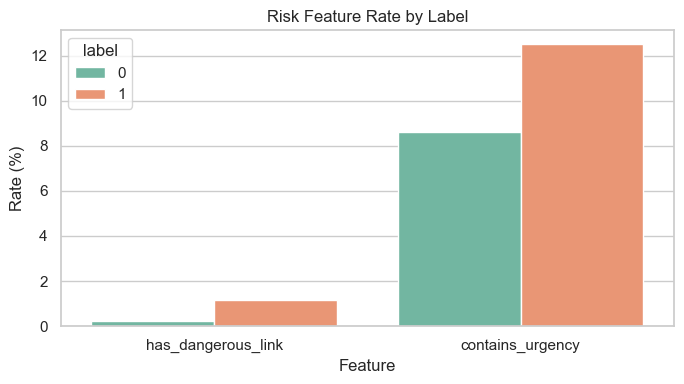

Saved: /Users/muhammadayyas/Documents/cyberguard-id/reports/eda/eda_risk_features_by_label.png


In [7]:
risk_cols = ["has_dangerous_link", "contains_urgency"]
risk_by_label = (df.groupby("label")[risk_cols].mean() * 100).round(2)
risk_by_platform = (df.groupby("platform")[risk_cols].mean() * 100).round(2)

display(risk_by_label)
display(risk_by_platform)

plot_df = risk_by_label.reset_index().melt(id_vars="label", value_vars=risk_cols, var_name="feature", value_name="pct")
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=plot_df, x="feature", y="pct", hue="label", palette="Set2", ax=ax)
ax.set_title("Risk Feature Rate by Label")
ax.set_xlabel("Feature")
ax.set_ylabel("Rate (%)")
plt.tight_layout()
out_path = REPORT_DIR / "eda_risk_features_by_label.png"
plt.savefig(out_path, dpi=200)
plt.show()
print(f"Saved: {out_path}")

## 6) Analisis Panjang Teks

,count,mean,std,min,25%,50%,75%,max
char_len,22399.0,537.357248,323.377755,12.0,187.0,667.0,795.0,4467.0
word_len,22399.0,78.864414,46.782247,1.0,30.0,95.0,114.0,672.0


,median_char_len,median_word_len
label,,
0,777.0,111.0
1,246.0,38.0


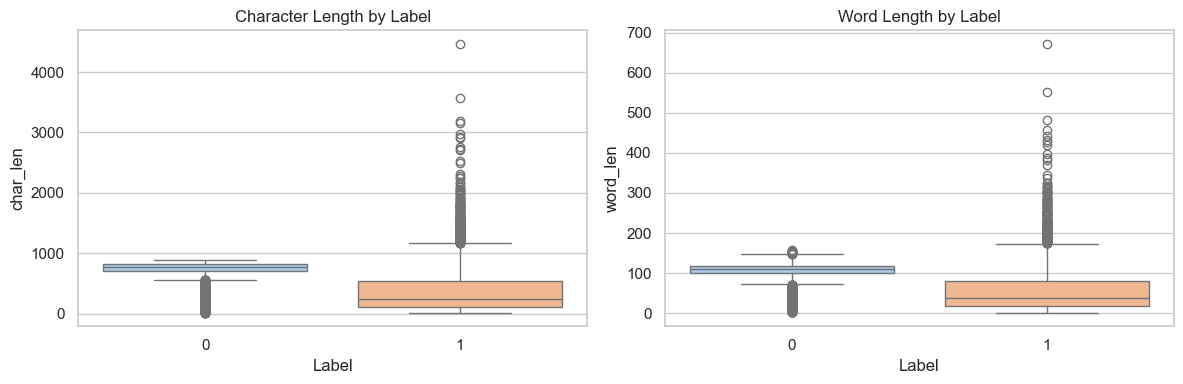

Saved: /Users/muhammadayyas/Documents/cyberguard-id/reports/eda/eda_text_length_by_label.png


In [12]:
df_len = df.copy()
df_len["char_len"] = df_len["processed_text"].fillna("").astype(str).str.len()
df_len["word_len"] = df_len["processed_text"].fillna("").astype(str).str.split().str.len()

display(df_len[["char_len", "word_len"]].describe().T)
display(df_len.groupby("label")[["char_len", "word_len"]].median().rename(columns={"char_len": "median_char_len", "word_len": "median_word_len"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(
    data=df_len,
    x="label",
    y="char_len",
    hue="label",
    palette="pastel",
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Character Length by Label")
sns.boxplot(
    data=df_len,
    x="label",
    y="word_len",
    hue="label",
    palette="pastel",
    dodge=False,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Word Length by Label")
for ax in axes:
    ax.set_xlabel("Label")
plt.tight_layout()
out_path = REPORT_DIR / "eda_text_length_by_label.png"
plt.savefig(out_path, dpi=200)
plt.show()
print(f"Saved: {out_path}")

## 7) Ringkasan Insight Kompetisi

In [ ]:
rows = len(df)
label0 = int(label_counts.get(0, 0))
label1 = int(label_counts.get(1, 0))
label0_pct = float(label_pct.get(0, 0.0))
label1_pct = float(label_pct.get(1, 0.0))

top_platform = platform_counts.iloc[0]
top_platform_name = str(top_platform["platform"])
top_platform_pct = float(top_platform["pct"])

link_gap = float(risk_by_label.loc[1, "has_dangerous_link"] - risk_by_label.loc[0, "has_dangerous_link"])
urgency_gap = float(risk_by_label.loc[1, "contains_urgency"] - risk_by_label.loc[0, "contains_urgency"])
imbalance_gap = abs(label1_pct - label0_pct)

leakage_platform_text = (
    ", ".join(potential_leakage_platforms)
    if potential_leakage_platforms
    else "tidak ada indikasi kuat (>=99% label tunggal)"
)
small_sample_platform_text = ", ".join(small_sample_platforms) if small_sample_platforms else "tidak ada"

if max(link_gap, urgency_gap) >= 20:
    risk_signal_note = "cukup kuat dan bisa dipakai sebagai sinyal awal model."
elif max(link_gap, urgency_gap) >= 10:
    risk_signal_note = "terlihat, tapi masih moderat dan perlu dikombinasikan dengan fitur lain."
else:
    risk_signal_note = "masih tipis, jadi perlu penambahan fitur agar pemisahan kelas lebih jelas."

summary_md = f"""
### Ringkasan

1. Total data: **{rows:,}** baris.
2. Distribusi label: normal **{label0_pct:.2f}%** ({label0:,}) vs phishing **{label1_pct:.2f}%** ({label1:,}).
3. Selisih distribusi label (imbalance gap): **{imbalance_gap:.2f} poin persentase**.
4. Platform dominan: **{top_platform_name}** sebesar **{top_platform_pct:.2f}%** dari total data.
5. Gap sinyal risiko antar label:
   - has_dangerous_link: **+{link_gap:.2f} poin persentase**
   - contains_urgency: **+{urgency_gap:.2f} poin persentase**
   - Interpretasi: {risk_signal_note}
6. Potensi leakage (label hampir deterministik): **{leakage_platform_text}**.
7. Platform dengan sampel kecil (perlu data tambahan): **{small_sample_platform_text}**.

display(Markdown(summary_md))


### Ringkasan EDA Kompetisi

1. Total data: **22,399** baris.
2. Distribusi label: normal **51.14%** (11,455) vs phishing **48.86%** (10,944).
3. Selisih distribusi label (imbalance gap): **2.28 poin persentase**.
4. Platform dominan: **News_Hoax** sebesar **45.79%** dari total data.
5. Gap sinyal risiko antar label:
   - has_dangerous_link: **+0.95 poin persentase**
   - contains_urgency: **+3.89 poin persentase**
   - Interpretasi: masih tipis, jadi perlu penambahan fitur agar pemisahan kelas lebih jelas.
6. Potensi leakage (label hampir deterministik): **News_Antara, News_Detik, News_Hoax, News_Kompas**.
7. Platform dengan sampel kecil (perlu data tambahan): **Email, WhatsApp**.

### Catatan Praktis
- Gunakan evaluasi per segmen kanal sebagai metrik wajib di laporan kompetisi.
- Tambahkan data komunikasi real-use (SMS/WhatsApp/Email) agar generalisasi model lebih realistis.
